In [2]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df=pd.read_csv('/content/Car_sales.csv')

In [4]:
df

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,02-02-2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,06-03-2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,01-04-2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,03-10-2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10-08-2011,62.777639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Volvo,V40,3.545,NaN,Passenger,24.40,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,9/21/2011,66.498812
153,Volvo,S70,15.245,NaN,Passenger,27.50,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,11/24/2012,70.654495
154,Volvo,V70,17.531,NaN,Passenger,28.80,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,6/25/2011,71.155978
155,Volvo,C70,3.493,NaN,Passenger,45.50,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,4/26/2011,101.623357


In [5]:
df.rename(columns={"__year_resale_value": "year_resale_value"}, inplace=True) # Rename column

In [6]:
df['Latest_Launch'] = pd.to_datetime(df['Latest_Launch'], errors='coerce') # Convert to datetime

In [7]:
df[df.select_dtypes(include='number').columns] = df.select_dtypes(include='number').fillna(df.median(numeric_only=True)) # Impute missing numerical values with median

In [11]:
df.isnull().sum() # check the number of null (missing) values in each column

,0
Manufacturer,0
Model,0
Sales_in_thousands,0
year_resale_value,0
Vehicle_type,0
Price_in_thousands,0
Engine_size,0
Horsepower,0
Wheelbase,0
Width,0


In [12]:
df.isnull().sum()[df.isnull().sum() > 0] # to only see columns that have missing values


,0


In [13]:
df

,Manufacturer,Model,Sales_in_thousands,year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.500,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2012-02-02,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.400,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,2011-06-03,91.370778
2,Acura,CL,14.114,18.225,Passenger,22.799,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,2012-01-04,72.030917
3,Acura,RL,8.588,29.725,Passenger,42.000,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,2011-03-10,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.990,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,2011-10-08,62.777639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Volvo,V40,3.545,14.180,Passenger,24.400,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,2011-02-10,66.498812
153,Volvo,S70,15.245,14.180,Passenger,27.500,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,2011-02-10,70.654495
154,Volvo,V70,17.531,14.180,Passenger,28.800,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,2011-02-10,71.155978
155,Volvo,C70,3.493,14.180,Passenger,45.500,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,2011-02-10,101.623357


In [14]:
from scipy import stats
print(df['Price_in_thousands'].mean())
print(df['Price_in_thousands'].median())
print(stats.mode(df['Price_in_thousands'], keepdims=True)) # mean, median, and mode of a column


27.332261146496823
22.799
ModeResult(mode=array([22.799]), count=array([3]))


In [15]:
print(df['Horsepower'].std())
print(df['Horsepower'].var())
# standard deviation and variance

56.52231893660753
3194.7725379715826


In [16]:
df.describe()
# summary statistics of all numerical columns

,Sales_in_thousands,year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
count,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157,157.000000
mean,52.998076,17.180318,27.332261,3.060510,185.894904,107.484076,71.146178,187.347134,3.377567,17.947134,23.847134,2011-05-26 02:17:34.777070080,76.979735
min,0.110000,5.160000,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,2011-02-10 00:00:00,23.276272
25%,14.114000,12.545000,18.145000,2.300000,150.000000,103.000000,68.400000,177.600000,2.975000,15.800000,21.000000,2011-02-10 00:00:00,60.727447
50%,29.450000,14.180000,22.799000,3.000000,177.500000,107.000000,70.550000,187.900000,3.342000,17.200000,24.000000,2011-02-10 00:00:00,72.030917
75%,67.956000,18.140000,31.930000,3.500000,215.000000,112.200000,73.400000,196.100000,3.778000,19.500000,26.000000,2011-07-12 00:00:00,89.401935
max,540.561000,67.550000,85.500000,8.000000,450.000000,138.700000,79.900000,224.500000,5.572000,32.000000,45.000000,2012-12-04 00:00:00,188.144323
std,68.029422,10.178562,14.268713,1.041311,56.522319,7.616872,3.441124,13.388708,0.626460,3.875905,4.241380,NaN,24.987338


In [17]:
df.corr(numeric_only=True) #correlation between numerical features

,Sales_in_thousands,year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
Sales_in_thousands,1.000000,-0.238623,-0.303049,0.019980,-0.197749,0.358171,0.140897,0.254980,0.008818,0.086520,-0.016674,-0.222234
year_resale_value,-0.238623,1.000000,0.783928,0.462297,0.670061,-0.050220,0.165410,0.037985,0.268868,0.260078,-0.334758,0.713331
Price_in_thousands,-0.303049,0.783928,1.000000,0.626264,0.836720,0.110727,0.329546,0.155968,0.522770,0.423697,-0.492416,0.897945
Engine_size,0.019980,0.462297,0.626264,1.000000,0.837347,0.472143,0.690389,0.541400,0.754120,0.663007,-0.733899,0.818166
Horsepower,-0.197749,0.670061,0.836720,0.837347,1.000000,0.286345,0.539233,0.393294,0.604644,0.499996,-0.610443,0.990442
Wheelbase,0.358171,-0.050220,0.110727,0.472143,0.286345,1.000000,0.683131,0.839606,0.649984,0.654036,-0.496808,0.258958
Width,0.140897,0.165410,0.329546,0.690389,0.539233,0.683131,1.000000,0.710316,0.717576,0.656375,-0.599029,0.512229
Length,0.254980,0.037985,0.155968,0.541400,0.393294,0.839606,0.710316,1.000000,0.624647,0.563418,-0.443537,0.353364
Curb_weight,0.008818,0.268868,0.522770,0.754120,0.604644,0.649984,0.717576,0.624647,1.000000,0.863809,-0.817539,0.606458
Fuel_capacity,0.086520,0.260078,0.423697,0.663007,0.499996,0.654036,0.656375,0.563418,0.863809,1.000000,-0.801349,0.501431


In [18]:
print(df['Sales_in_thousands'].skew())
print(df['Sales_in_thousands'].kurtosis())
# skewness and kurtosis

3.408518366470572
17.55734423299965


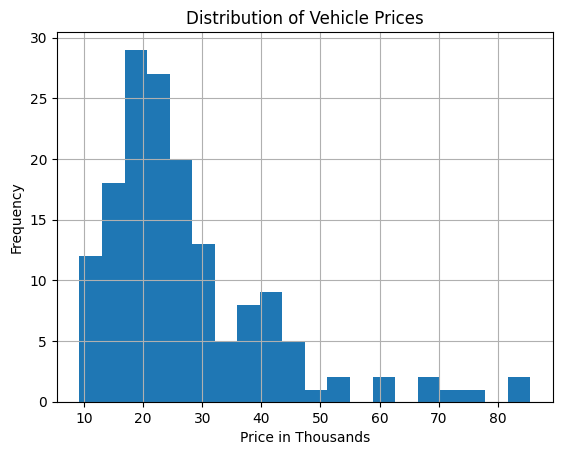

In [19]:
df['Price_in_thousands'].hist(bins=20)
plt.title('Distribution of Vehicle Prices')
plt.xlabel('Price in Thousands')
plt.ylabel('Frequency')
plt.show()  # histogram of vehicle prices

<Axes: xlabel='Horsepower'>

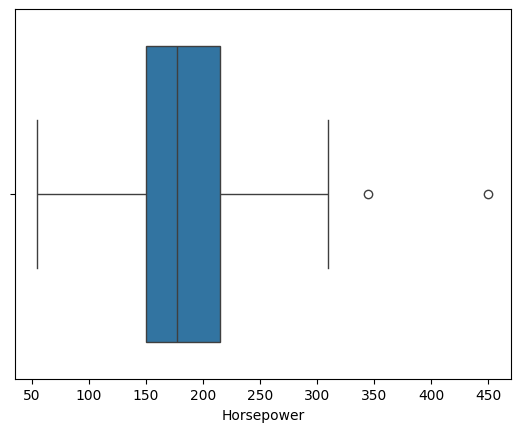

In [20]:
sns.boxplot(x=df['Horsepower']) # a boxplot to detect outliers in horsepower


<Axes: xlabel='Horsepower', ylabel='Price_in_thousands'>

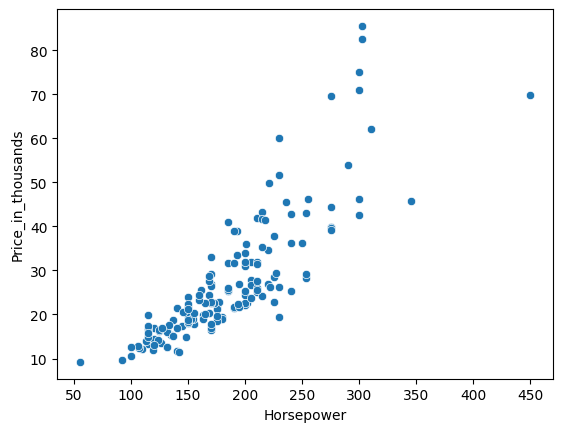

In [21]:
sns.scatterplot(x='Horsepower', y='Price_in_thousands', data=df)
# a scatter plot of price vs. horsepower

<Axes: >

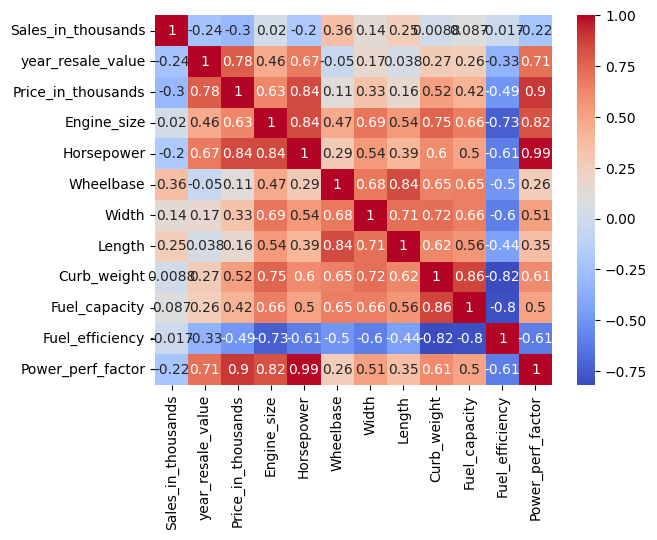

In [22]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
# a heatmap of correlation matrix

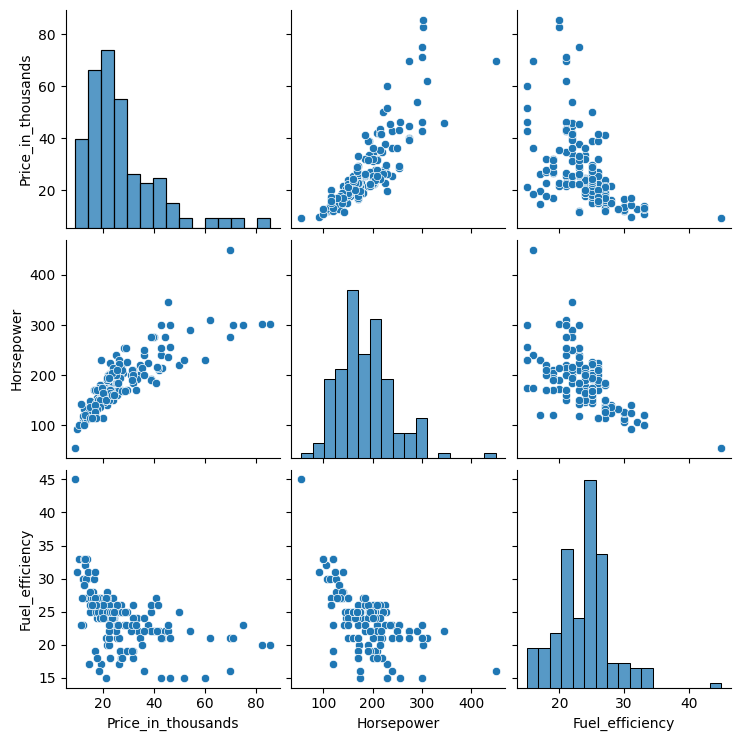

In [23]:
sns.pairplot(df[['Price_in_thousands', 'Horsepower', 'Fuel_efficiency']])
# a pair plot for selected features

In [24]:
df.groupby('Vehicle_type')['Price_in_thousands'].mean()
# group by vehicle type and calculate average price

,Price_in_thousands
Vehicle_type,
Car,26.234098
Passenger,27.720405


In [25]:
df['Manufacturer'].value_counts() #  count number of models per manufacturer

,count
Manufacturer,
Ford,11
Dodge,11
Chevrolet,9
Mercedes-B,9
Toyota,9
Chrysler,7
Mitsubishi,7
Nissan,7
Mercury,6


<Axes: xlabel='Manufacturer'>

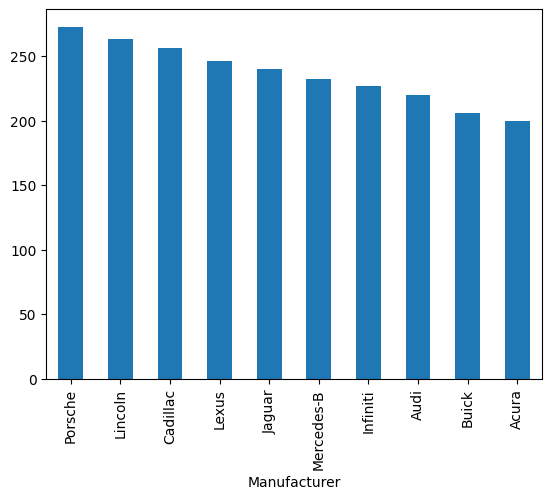

In [26]:
df.groupby('Manufacturer')['Horsepower'].mean().nlargest(10).plot(kind='bar')
# to plot average horsepower by manufacturer (top 10 only)

In [27]:
from scipy.stats import ttest_ind
t1 = df[df['Vehicle_type'] == 'Passenger']['Price_in_thousands']
t2 = df[df['Vehicle_type'] != 'Passenger']['Price_in_thousands']
ttest_ind(t1, t2, nan_policy='omit')
# a t-test between two vehicle types' prices

TtestResult(statistic=np.float64(0.5720797208644113), pvalue=np.float64(0.5680967333998654), df=np.float64(155.0))

In [30]:
from scipy.stats import zscore
df['z_score_price'] = zscore(df['Price_in_thousands'].fillna(df['Price_in_thousands'].median()))
# calculate z-scores for price to detect outliers

In [31]:
df[df['z_score_price'].abs() > 3]
 # to identify rows with outliers using z-score

,Manufacturer,Model,Sales_in_thousands,year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor,z_score_price
95,Mercedes-B,SL-Class,3.311,58.600,Passenger,82.60,5.0,302.0,99.0,71.3,177.1,4.125,21.1,20.0,2011-02-10,139.982294,3.885746
99,Mercedes-B,CL500,0.954,14.180,Passenger,85.50,5.0,302.0,113.6,73.1,196.6,4.115,23.2,20.0,2011-04-11,141.100985,4.089638
125,Porsche,Carrera Coupe,1.280,60.625,Passenger,71.02,3.4,300.0,92.6,69.5,174.5,3.032,17.0,21.0,2011-02-10,134.390975,3.071583
126,Porsche,Carrera Cabrio,1.866,67.550,Passenger,74.97,3.4,300.0,92.6,69.5,174.5,3.075,17.0,23.0,2011-07-11,135.914710,3.349299


In [32]:
pd.cut(df['Price_in_thousands'], bins=[0,20,40,60,100], labels=['Low','Mid','High','Luxury']).value_counts()
# create bins for vehicle prices and count them

,count
Price_in_thousands,
Mid,78
Low,55
High,16
Luxury,8


In [33]:
df['Launch_Year'] = df['Latest_Launch'].dt.year
# to extract year from launch date

<Axes: xlabel='Launch_Year'>

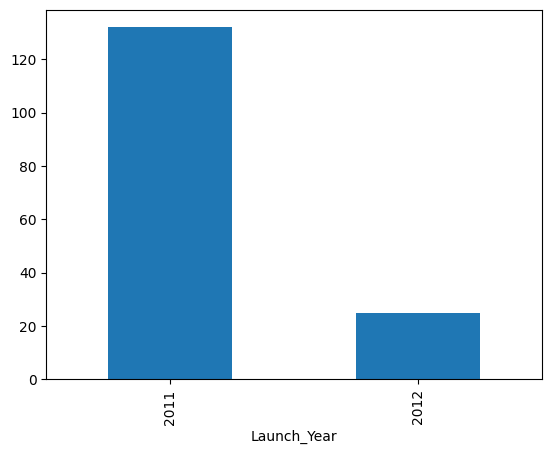

In [34]:
df['Launch_Year'].value_counts().sort_index().plot(kind='bar')
# number of vehicles launched each year

<Axes: xlabel='Vehicle_type', ylabel='count'>

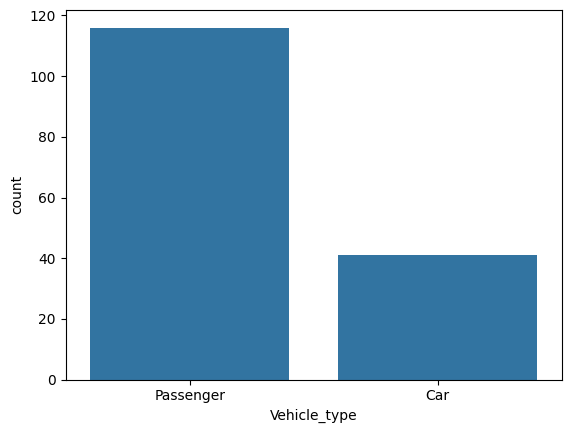

In [35]:
sns.countplot(x='Vehicle_type', data=df)
# to plot a countplot of vehicle types